In [9]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [19]:
# Define state
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    Label_bmi:str
    bmi:float



In [26]:
def calculate_bmi(state:BMIState)->BMIState:
    weight=state["weight_kg"]
    height=state["height_m"]

    bmi = weight /( height ** 2)
    state["bmi"] = round(bmi,2)
    return state


def Label_bmi(state:BMIState)->BMIState:
    bmi = state["bmi"]
    if bmi < 24.5 :
        state["Label_bmi"]="fit"
    elif bmi >24.5 and bmi < 32:
        state["Label_bmi"]="Overweight and Obesse"
    return state


In [27]:
#Define Graph
graph=StateGraph(BMIState)

#add Nodes to the graph
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node("Label_bmi",Label_bmi)
#add Edge to the graph
graph.add_edge(START,"calculate_bmi")
graph.add_edge("calculate_bmi","Label_bmi")
graph.add_edge("Label_bmi",END)

#compile the graph
workflow = graph.compile()

In [ ]:
initial_state = {"weight_kg":70,"height_m":1.69}
final_state = workflow.invoke(initial_state)
# print(final_state)
print(final_state["bmi"]*10000 , final_state["Label_bmi"])

{'weight_kg': 70, 'height_m': 1.69, 'Label_bmi': 'Overweight and Obesse', 'bmi': 24.51}


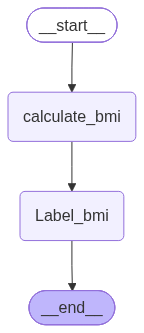

In [30]:
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())